# **Importing the libraries**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import libraries for data handling, EAR calculation, and model building
import os
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input
from scipy.spatial import distance as dist
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.applications import MobileNetV2

# **Calculating Eye and mouth aspect ratio**

In [3]:
def calculate_ear(eye):
    """
    Calculate the Eye Aspect Ratio (EAR) for a given set of eye landmarks.
    :param eye: List of (x, y) coordinates for the eye landmarks.
    :return: EAR value.
    """
    # Compute distances between the two sets of vertical eye landmarks
    A = dist.euclidean(eye[1], eye[5])
    B = dist.euclidean(eye[2], eye[4])

    # Compute the distance between the horizontal eye landmarks
    C = dist.euclidean(eye[0], eye[3])

    # Calculate EAR
    ear = (A + B) / (2.0 * C)
    return ear


def calculate_mar(mouth):
    """
    Calculate the Mouth Aspect Ratio (MAR) for a given set of mouth landmarks.
    :param mouth: List of (x, y) coordinates for the mouth landmarks.
    :return: MAR value.
    """
    A = dist.euclidean(mouth[2], mouth[10])
    B = dist.euclidean(mouth[4], mouth[8])
    C = dist.euclidean(mouth[0], mouth[6])
    mar = (A + B) / (2.0 * C)
    return mar


# **Preprocessing and augmenting image data**

In [4]:
# Dataset directories
train_dir = '/content/drive/MyDrive/Dataset/train'
test_dir = '/content/drive/MyDrive/Dataset/test'

# Parameters
BATCH_SIZE = 32

# ----- Eyes Data Preprocessing -----
eye_train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

eye_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

eye_train_generator = eye_train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=BATCH_SIZE,
    subset='training',
    class_mode='categorical',
    classes=['1_Closed', '2_Open']
)

eye_val_generator = eye_val_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=BATCH_SIZE,
    subset='validation',
    class_mode='categorical',
    shuffle = False,
    classes=['1_Closed', '2_Open']
)

# ----- Yawn Data Preprocessing -----
yawn_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

yawn_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

yawn_train_generator = yawn_train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    subset='training',
    class_mode='categorical',
    classes=['3_no_yawn', '4_yawn']
)

yawn_val_generator = yawn_val_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    subset='validation',
    class_mode='categorical',
    shuffle = False,
    classes=['3_no_yawn', '4_yawn']
)


Found 1162 images belonging to 2 classes.
Found 290 images belonging to 2 classes.
Found 1159 images belonging to 2 classes.
Found 289 images belonging to 2 classes.


In [ ]:
# print("Train batches per epoch:", len(train_generator))
# print("Validation batches per epoch:", len(validation_generator))

# **Defining and Compiling a Convolutional Neural Network (CNN)**

# for eye state

In [5]:
# Define the model using an Input layer for the input shape
IMG_SIZE = (64, 64)
eye_model = Sequential([
    Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),  # Define the input shape with Input layer
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

# Compile the model
eye_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

eye_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,458 (2.61 MB)

 Trainable params: 683,458 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

# for yawn state

In [6]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(2, activation='softmax')(x)

yawn_model = Model(
    inputs=base_model.input,
    outputs=output
    )

yawn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )

yawn_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,722 (9.24 MB)

 Trainable params: 2,388,354 (9.11 MB)

 Non-trainable params: 34,368 (134.25 KB)

# **Training the CNN Model with Early Stopping and Visualizing Accuracy**

# train eye model

In [9]:
# # Early stopping to avoid overfitting
# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)


# Train the eye model
history_eye = eye_model.fit(
    eye_train_generator,
    validation_data=eye_val_generator,
    epochs=30,
    # callbacks=[early_stop, reduce_lr]
)



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 257s 7s/step - accuracy: 0.5739 - loss: 0.6439 - val_accuracy: 0.8207 - val_loss: 0.4018
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 355ms/step - accuracy: 0.8529 - loss: 0.4141 - val_accuracy: 0.7966 - val_loss: 0.4868
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 357ms/step - accuracy: 0.8786 - loss: 0.3417 - val_accuracy: 0.8724 - val_loss: 0.2880
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 352ms/step - accuracy: 0.9164 - loss: 0.2413 - val_accuracy: 0.9069 - val_loss: 0.2392
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 349ms/step - accuracy: 0.9188 - loss: 0.2204 - val_accuracy: 0.9207 - val_loss: 0.2021
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 14s 367ms/step - accuracy: 0.9273 - loss: 0.2059 - val_accuracy: 0.9345 - val_loss: 0.1944
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 354ms/step - accuracy: 0.9354 - loss: 0.1948 - val_accuracy: 0.8897 - val_loss: 0.2612
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 24s 433ms/step - accuracy: 0.9244 - loss: 0.2216 - val_accura

In [10]:
eye_model.save('fatigue_Detection_eyes.h5')
print("Model saved as fatigue_Detection_eyes.h5")


Model saved as fatigue_Detection_eyes.h5


# train mouth/yawn model

In [ ]:
# Train the yawn model
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=1)

history = yawn_model.fit(
    yawn_train_generator,
    validation_data=yawn_val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 486s 11s/step - accuracy: 0.6456 - loss: 0.8473 - val_accuracy: 0.5675 - val_loss: 0.7779 - learning_rate: 1.0000e-04
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 340s 9s/step - accuracy: 0.8095 - loss: 0.4320 - val_accuracy: 0.5675 - val_loss: 0.8612 - learning_rate: 1.0000e-04
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 365s 10s/step - accuracy: 0.8985 - loss: 0.2611 - val_accuracy: 0.5467 - val_loss: 1.0599 - learning_rate: 3.0000e-05
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 385s 10s/step - accuracy: 0.8855 - loss: 0.3154 - val_accuracy: 0.5467 - val_loss: 1.1043 - learning_rate: 9.0000e-06
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 358s 10s/step - accuracy: 0.9206 - loss: 0.2161 - val_accuracy: 0.5571 - val_loss: 1.1051 - learning_rate: 2.7000e-06


In [ ]:
yawn_model.save('fatigue_Detection_yawn.h5')
print("Model saved as fatigue_Detection_yawn.h5")

Model saved as fatigue_Detection_yawn.h5


# **Calculating Performance Metrics**


# **Training and Validation Accuracy and Loss**

# for eye state #

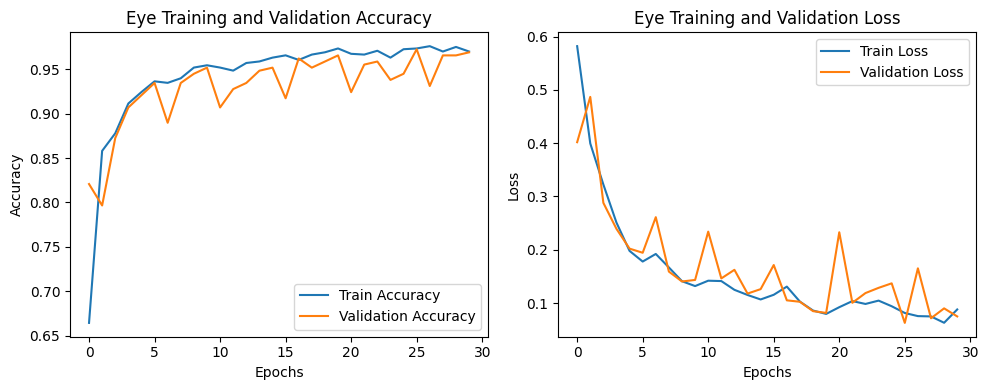

Training Accuracy: 0.9699
Validation Accuracy: 0.9690


In [11]:
import matplotlib.pyplot as plt

# Create a 1-row, 2-column subplot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # Adjust width/height as needed

# Plot training and validation accuracy
axes[0].plot(history_eye.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_eye.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Eye Training and Validation Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Plot training and validation loss
axes[1].plot(history_eye.history['loss'], label='Train Loss')
axes[1].plot(history_eye.history['val_loss'], label='Validation Loss')
axes[1].set_title('Eye Training and Validation Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print final accuracies
final_train_acc = history_eye.history['accuracy'][-1]
final_val_acc = history_eye.history['val_accuracy'][-1]

print(f"Training Accuracy: {final_train_acc:.4f}")
print(f"Validation Accuracy: {final_val_acc:.4f}")


# for yawn #

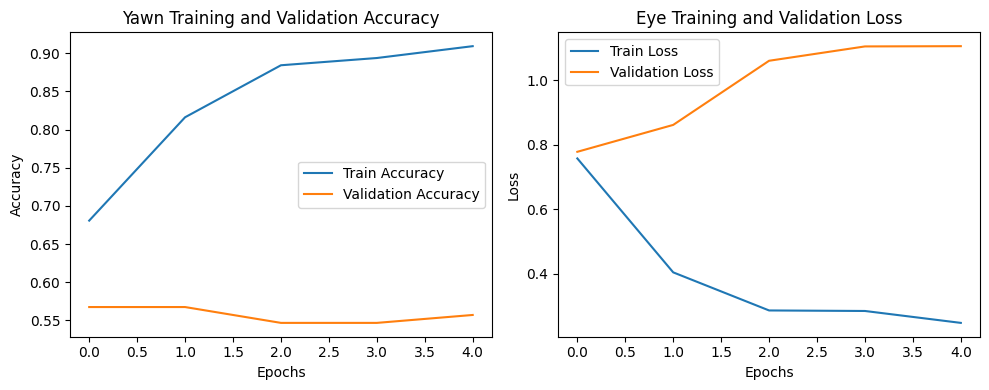

Training Accuracy: 0.9094
Validation Accuracy: 0.5571


In [ ]:
import matplotlib.pyplot as plt

# Create a 1-row, 2-column subplot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # Adjust width/height as needed

# Plot training and validation accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Yawn Training and Validation Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Plot training and validation loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Eye Training and Validation Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print final accuracies
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"Training Accuracy: {final_train_acc:.4f}")
print(f"Validation Accuracy: {final_val_acc:.4f}")


In [12]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
import numpy as np

# Predict only that many steps
y_pred_probs = eye_model.predict(eye_val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = eye_val_generator.classes
class_labels = list(eye_val_generator.class_indices.keys())


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step


# **Confusion Matrix and classification report**

# for eye #

Classification Report:
              precision    recall  f1-score   support

    1_Closed       0.96      0.98      0.97       145
      2_Open       0.98      0.96      0.97       145

    accuracy                           0.97       290
   macro avg       0.97      0.97      0.97       290
weighted avg       0.97      0.97      0.97       290



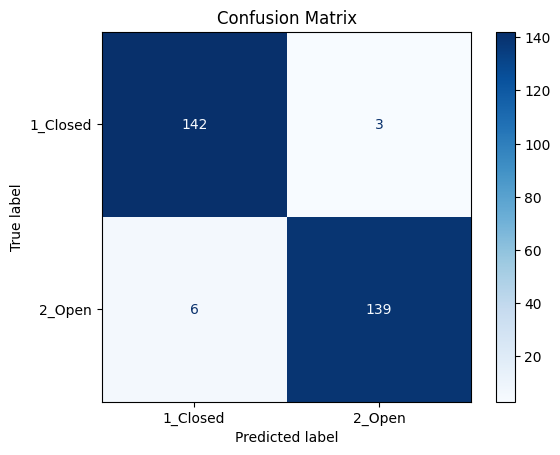

In [13]:
# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Get predictions from the yawn model
yawn_pred_probs = yawn_model.predict(yawn_val_generator)
yawn_pred = np.argmax(yawn_pred_probs, axis=1)

# Get true labels
yawn_true = yawn_val_generator.classes

# Get class label names
yawn_labels = list(yawn_val_generator.class_indices.keys())


10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step


# for yawn #

Classification Report (Yawn Detection):
              precision    recall  f1-score   support

   3_no_yawn       0.95      0.14      0.25       145
      4_yawn       0.54      0.99      0.70       144

    accuracy                           0.57       289
   macro avg       0.75      0.57      0.47       289
weighted avg       0.75      0.57      0.47       289



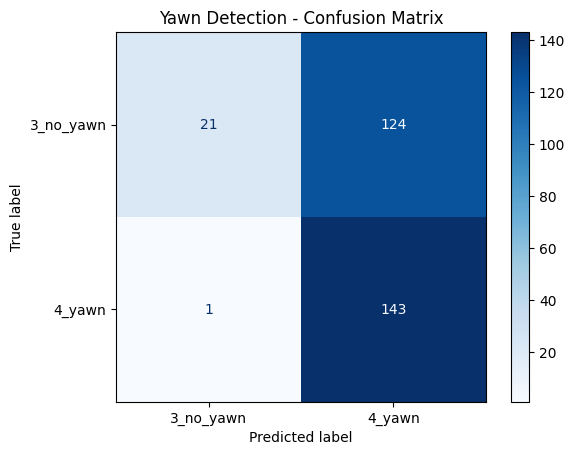

In [ ]:


# Classification Report
print("Classification Report (Yawn Detection):")
print(classification_report(yawn_true, yawn_pred, target_names=yawn_labels))

# Confusion Matrix
cm_yawn = confusion_matrix(yawn_true, yawn_pred)
disp_yawn = ConfusionMatrixDisplay(confusion_matrix=cm_yawn, display_labels=yawn_labels)
disp_yawn.plot(cmap='Blues')
plt.title("Yawn Detection - Confusion Matrix")
plt.show()


# **PR Curve**

# for eye state #

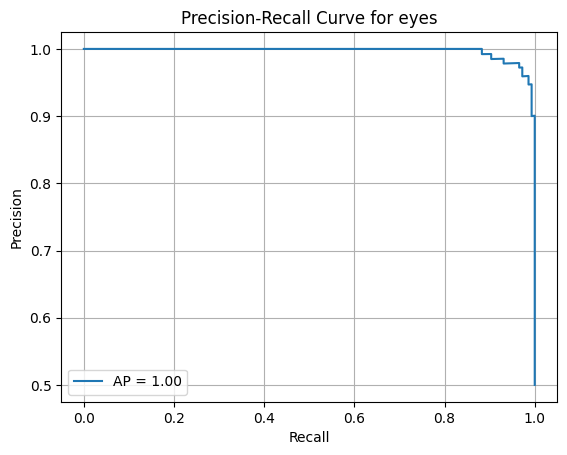

In [14]:
# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_true, y_pred_probs[:, 1])
avg_precision = average_precision_score(y_true, y_pred_probs[:, 1])
plt.plot(recall, precision, label=f'AP = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for eyes')
plt.legend()
plt.grid()
plt.show()

# for yawn state #

# **Real-Time Drowsiness Detection Using Eye and Mouth Aspect Ratios**

In [ ]:
# Precision-Recall curve
precision, recall, _ = precision_recall_curve(yawn_true, yawn_pred_probs[:, 1])
avg_precision = average_precision_score(yawn_true, yawn_pred_probs[:, 1])
plt.plot(recall, precision, label=f'AP = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for yawn')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Initialize dlib face detector and landmark predictor
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("/content/drive/MyDrive/shape_predictor_68_face_landmarks.dat")

# Parameters
EAR_THRESHOLD = 0.25
MAR_THRESHOLD = 0.50  # Adjust this threshold for mouth opening sensitivity
CONSECUTIVE_FRAMES = 20
frame_counter = 0

# Load video
cap = cv2.VideoCapture("/kaggle/input/drowsinesstest3/test3.mp4")

frame_count = 0
max_frames = 200  # Limit to 50 frames for testing

# Frame processing loop
while frame_count < max_frames:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)

    for face in faces:
        shape = predictor(gray, face)
        landmarks = np.array([[shape.part(i).x, shape.part(i).y] for i in range(68)])

        # Eye landmarks (left and right eye)
        left_eye = landmarks[36:42]
        right_eye = landmarks[42:48]

        # Mouth landmarks
        mouth = landmarks[48:68]

        # Calculate EAR
        left_ear = calculate_ear(left_eye)
        right_ear = calculate_ear(right_eye)
        ear = (left_ear + right_ear) / 2.0

        # Calculate MAR
        mar = calculate_mar(mouth)

        # Print EAR and MAR values for debugging
        print(f"EAR: {ear}, MAR: {mar}")

        # Check for drowsiness alert based on both EAR and MAR
        if ear < EAR_THRESHOLD or mar > MAR_THRESHOLD:
            frame_counter += 1
            if frame_counter >= CONSECUTIVE_FRAMES:
                cv2.putText(frame, "DROWSINESS ALERT!", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
        else:
            frame_counter = 0

        # Draw landmarks for debugging purposes
        for (x, y) in left_eye:
            cv2.circle(frame, (x, y), 2, (0, 255, 0), -1)
        for (x, y) in right_eye:
            cv2.circle(frame, (x, y), 2, (0, 255, 0), -1)
        for (x, y) in mouth:
            cv2.circle(frame, (x, y), 2, (0, 0, 255), -1)

    # Display the frame with drawn landmarks
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    frame_count += 1

cap.release()
